## 1) 타이타닉 데이터
* 캐글에서 제공하는 타이나틱 탑승자 데이터 기반으로 생존자 예측을 사이킷런으로 수행
* 데이터 내용
  * Passerngerid : 탑승자 데이터 일련번호
  * survived : 생존여부(0=사망 / 1=생존)
  * pclass : 티켓의 선실 등급(1=일등석 / 2=이등석 / 3=삼등석)
  * sex : 탑승자 성별
  * name : 탑승자 이름
  * Age : 탑승자 나이
  * sibsp : 같이 탑승한 형재자매 또는 배우자 인원 수
  * parch : 같이 탑승한 부모님 또는 어린이 인원 수
  * ticket : 티켓 번호
  * fare :요금
  * cabin : 선실번호
  * embarked : 중간 정착 항구 (C=Cherbourg, Q=Queenstown, S=Southampton)

In [3]:
# 데이터 로드

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #맷플롯립에 기반하나 세련된 비주얼과 쉬운 API, 편리한 판다스 DataFrame연동 등 특징 가진 시각화 패키지
%matplotlib inline

titanic_df = pd.read_csv(r'./kaggle/titanic/titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## 2) feature 확인 및 가공(1)

In [4]:
# 데이터 칼럼 타입 확인
print('\n---학습 데이터 정보---')
print(titanic_df.info())


---학습 데이터 정보---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [5]:
# Null 값 처리

titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
titanic_df['Cabin'].fillna('N', inplace=True)
titanic_df['Embarked'].fillna('N', inplace=True)
print('데이터 세트 Null값 개수 : ', titanic_df.isnull().sum().sum())

데이터 세트 Null값 개수 :  0


In [6]:
# 문자열 피처

print(' Sex 값 분포 : \n', titanic_df['Sex'].value_counts())
print('\nCabin 값 분포 : \n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 : \n', titanic_df['Embarked'].value_counts())

 Sex 값 분포 : 
 male      577
female    314
Name: Sex, dtype: int64

Cabin 값 분포 : 
 N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
C128             1
B37              1
C32              1
C85              1
A23              1
Name: Cabin, Length: 148, dtype: int64

 Embarked 값 분포 : 
 S    644
C    168
Q     77
N      2
Name: Embarked, dtype: int64


In [7]:
# Cabin 피처 처리
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1] #맨 첫자리만 추출
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [8]:
# 데이터 탐색 : 어떤 유형의 승객이 생존 확률이 높았는지 확인 - 성별에 따라
titanic_df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

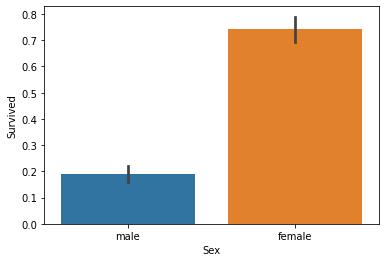

In [9]:
sns.barplot(x='Sex', y='Survived', data=titanic_df)

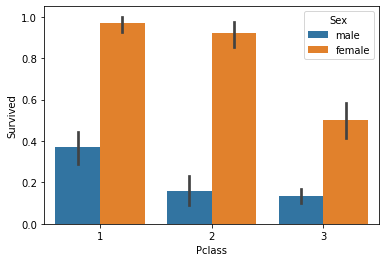

In [10]:
# 데이터 탐색 : 어떤 유형의 승객이 생존 확률이 높았는지 확인 - 부에 따라(객실 등급)
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

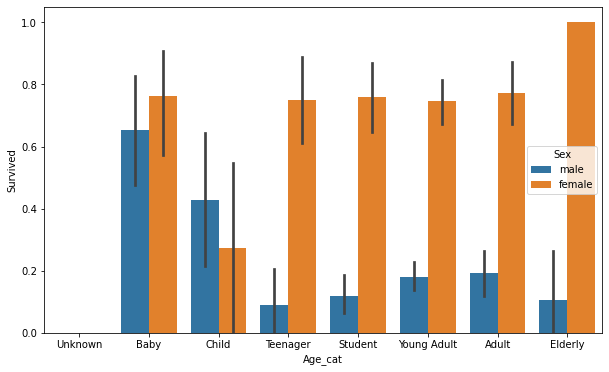

In [12]:
# 데이터 탐색 : 어떤 유형의 승객이 생존 확률이 높았는지 확인 - 나이에 따라

def get_category(age):
    cat=''
    if age <= -1 : cat='Unknown'
    elif age <= 5 : cat='Baby'
    elif age <= 12 : cat='Child'
    elif age <= 18 : cat='Teenager'
    elif age <= 25 : cat='Student'
    elif age <= 35 : cat='Young Adult'
    elif age <= 60 : cat='Adult'
    else : cat='Elderly'
    
    return cat

plt.figure(figsize=(10, 6)) #막대그래프 크기 figure을 더 크게 설정
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

# Sex, Age, Pclass가 생존을 좌우하는 중요 피처임을 알 수 있음

In [13]:
# 남은 문자열 카테고리 피처를 숫자형 카테고리 피처로 변환 : 함수를 생성해 여러 칼럼을 한번에 변환

from sklearn import preprocessing

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = preprocessing.LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])
    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


## 3) feature 확인 및 가공(2)
* 함수로 만들어 재사용할 수 있도록 하기

In [22]:
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 속성 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

## 4) 학습/테스트 데이터셋 추출

In [24]:
# 원본 데이터 재로딩. 피처 데이터 세트와 레이블 데이터 세트 추출
titanic_df = pd.read_csv(r'./kaggle/titanic/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
x_titanic_df = titanic_df.drop('Survived', axis=1)

x_titanic_df = transform_features(x_titanic_df)

In [25]:
# train_test_split() API를 이용해 별도의 테스트 데이터셋 추출
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

## 5) ML 알고리즘으로 생존자 예측
* 결정 트리(DecisionTreeClassifier 클래스), 랜덤 포레스트(RandomForestClassifier 클래스), 로지스틱 회귀(LogisticRegrssion 클래스) 이용
* 분리한 학습/테스트 데이터를 기반으로 fit(머신러닝 모델 학습), predict(예측)함
* 예측 성능 평가는 정확도 -> accuracy_score() API 이용

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#결정트리, 랜덤포레스트, 로지스틱 회귀 위한 사이킷런 classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression()

# 의사결정트리 학습, 예측, 평가
dt_clf.fit(x_train, y_train)
dt_pred = dt_clf.predict(x_test)
print('DecisionTreeClassifer 정확도 : {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

#랜덤포레스트 학습, 예측, 평가
rf_clf.fit(x_train, y_train)
rf_pred = rf_clf.predict(x_test)
print('RandomForestClassifier 정확도 : {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# 로지스틱회귀 학습, 예측, 평가
lr_clf.fit(x_train, y_train)
lr_pred = lr_clf.predict(x_test)
print('LogisticRegression 정확도 : {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifer 정확도 : 0.7877
RandomForestClassifier 정확도 : 0.7877
LogisticRegression 정확도 : 0.8492


C:\Users\lumos\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6) 교차 검증으로 결증 트리 모델 평가

In [33]:
# KFold 방법 사용
from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    kfold = KFold(n_splits=folds) #폴드 세트를 5개인 KFold 객체 생성
    scores = [] # 폴드 수만큼 예측 결과 저장을 위한 리스트 객체 생성
    
    for iter_count, (train_index, test_index) in enumerate(kfold.split(x_titanic_df)):
        x_train, x_test = x_titanic_df.values[train_index], x_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        clf.fit(x_train, y_train)
        predictions = clf.predict(x_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)
        print('교차 검증 {0} 정확도 : {1:.4f}'.format(iter_count, accuracy))
    
    mean_score = np.mean(scores)
    print('평균 정확도 : {0:.4f}'.format(mean_score))

exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도 : 0.7542
교차 검증 1 정확도 : 0.7809
교차 검증 2 정확도 : 0.7865
교차 검증 3 정확도 : 0.7697
교차 검증 4 정확도 : 0.8202
평균 정확도 : 0.7823


In [37]:
# cross_val_score() API 방법 사용
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, x_titanic_df, y_titanic_df, cv=5)
for iter_count, accuracy in enumerate(scores):
    print('교차 검증 {0} 정확도 : {1:.4f}'.format(iter_count, accuracy))
print('평균 정확도 : {0:.4f}'.format(np.mean(scores)))

교차 검증 0 정확도 : 0.7430
교차 검증 1 정확도 : 0.7753
교차 검증 2 정확도 : 0.7921
교차 검증 3 정확도 : 0.7865
교차 검증 4 정확도 : 0.8427
평균 정확도 : 0.7879


In [39]:
# GridSearchCV로 의사결정트리의 최적 하이퍼 파라미터 값 찾고 예측 성능 측정
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2, 3, 5, 10], 'min_samples_split':[2, 3, 5], 'min_samples_leaf':[1, 5, 8]}
grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(x_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터 : ', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도 : {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

dpredictions = best_dclf.predict(x_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도 : {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터 :  {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도 : 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도 : 0.8715
